# **🎓 College Event Feedback Analysis**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Event_Feedback.csv to Event_Feedback.csv


# **1.Import Libraries and Load Data**

In [ ]:
#install required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob

In [ ]:
#load data
df = pd.read_csv('Event_Feedback.csv')
df.head()

,Event Name,Department,Rating,Comment,Event Date
0,Tech Talk,CSE,4,"Great event, learned a lot!",2024-01-10
1,Workshop,ECE,5,Very well organized and fun.,2024-02-15
2,Cultural Fest,MECH,3,"Good, but timing could be better.",2024-03-01
3,Seminar,CSE,4,Speaker was very engaging.,2024-03-25
4,Hackathon,IT,5,Loved it! More like this please.,2024-04-10


# **2.Clean and Prepare Data**

In [ ]:
# Check for missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values in the specified columns
df.dropna(subset=['Comment', 'Rating'], inplace=True)

# Confirm no more missing values in the relevant columns
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Event Name    0
Department    0
Rating        0
Comment       0
Event Date    0
dtype: int64

Missing values after cleaning:
Event Name    0
Department    0
Rating        0
Comment       0
Event Date    0
dtype: int64


# **3.Add Sentiment Score (Polarity)**

In [ ]:
# Calculate polarity score for each comment
df['Sentiment_Polarity'] = df['Comment'].apply(lambda x: TextBlob(x).sentiment.polarity)
# Classify overall sentiment
df['Sentiment_Label'] = df['Sentiment_Polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)
df[['Comment', 'Sentiment_Polarity', 'Sentiment_Label']].head()

,Comment,Sentiment_Polarity,Sentiment_Label
0,"Great event, learned a lot!",1.0000,Positive
1,Very well organized and fun.,0.2500,Positive
2,"Good, but timing could be better.",0.6000,Positive
3,Speaker was very engaging.,0.5200,Positive
4,Loved it! More like this please.,0.6875,Positive


# **4.Perform Sentiment Analysis**


Sentiment Breakdown:
Sentiment_Label
Positive    5
Neutral     2
Name: count, dtype: int64


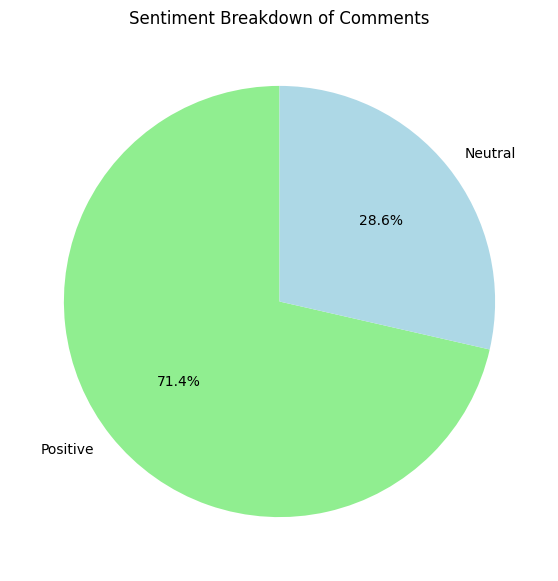

In [ ]:
# Create a function to label sentiment based on polarity score
def label_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the sentiment analysis to the 'Comment' column
df['Sentiment_Polarity'] = df['Comment'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['Sentiment_Label'] = df['Sentiment_Polarity'].apply(label_sentiment)

# Count and visualize the number of comments for each sentiment label
sentiment_counts = df['Sentiment_Label'].value_counts()
print("\nSentiment Breakdown:")
print(sentiment_counts)

plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#90EE90', '#ADD8E6', '#FFB6C1'])
plt.title("Sentiment Breakdown of Comments")
plt.ylabel('')
plt.show()



# **5.Visualizations: Rating & Sentiment Distribution**

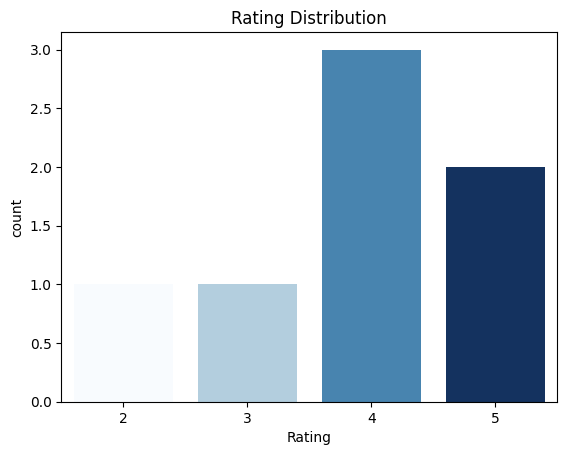

In [ ]:
#Rating distribution
sns.countplot(data=df, x='Rating', hue='Rating', palette='Blues', legend=False)
plt.title('Rating Distribution')
plt.show()

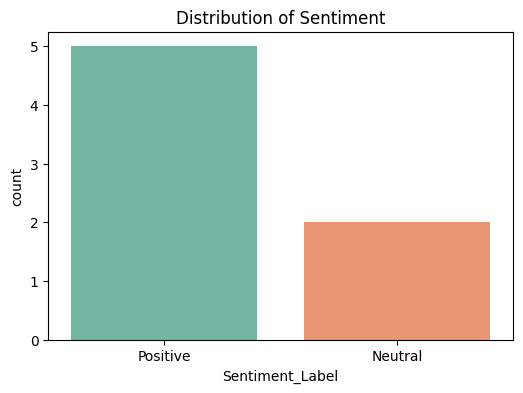

In [ ]:
# Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment_Label', hue='Sentiment_Label', palette='Set2', legend=False)
plt.title('Distribution of Sentiment')
plt.show()

# **6.Word Clouds for Sentiment**

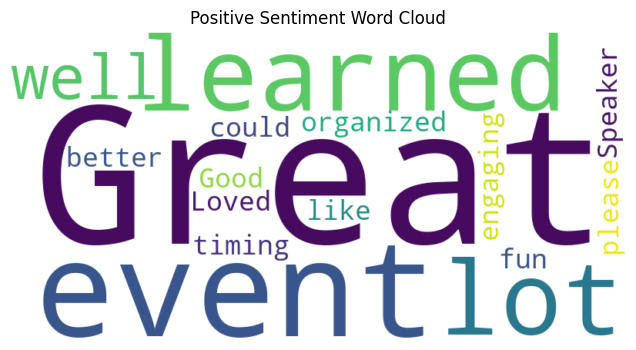

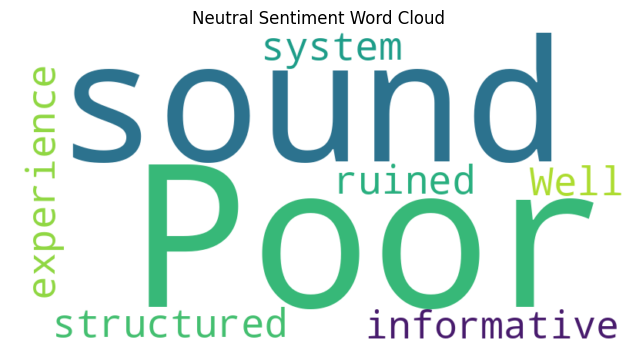

No usable content found for 'Negative' sentiment.


In [ ]:
def plot_wordcloud(sentiment):
    comments = df[df['Sentiment_Label'] == sentiment]['Comment']
    text = " ".join(comments.dropna().astype(str))

    if text.strip():
        wordcloud = WordCloud(
            width=800, height=400,
            background_color='white',
            stopwords=STOPWORDS
        ).generate(text)

        plt.figure(figsize=(8, 4))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"{sentiment} Sentiment Word Cloud")
        plt.show()
    else:
        print(f"No usable content found for '{sentiment}' sentiment.")

plot_wordcloud("Positive")
plot_wordcloud("Neutral")
plot_wordcloud("Negative")

# **7.Polarity vs Rating Chart**

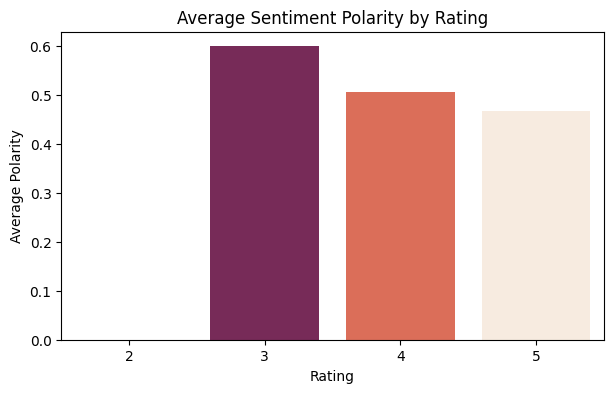

In [ ]:
# Average polarity per rating
avg_polarity = df.groupby('Rating')['Sentiment_Polarity'].mean().reset_index()
plt.figure(figsize=(7, 4))
sns.barplot(data=avg_polarity, x='Rating', y='Sentiment_Polarity', hue='Rating', palette='rocket', legend=False)
plt.title("Average Sentiment Polarity by Rating")
plt.ylabel("Average Polarity")
plt.show()

# **8.Coorelation Heatmap**

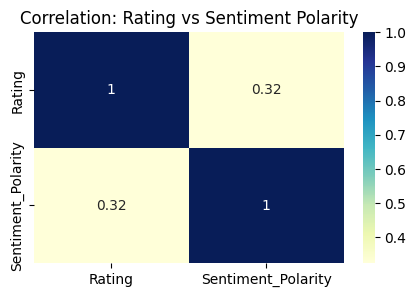

In [ ]:
plt.figure(figsize=(5, 3))
sns.heatmap(df[['Rating', 'Sentiment_Polarity']].corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation: Rating vs Sentiment Polarity")
plt.show()

# **9.Sentiment by Department**

([0, 1, 2, 3, 4],
 [Text(0, 0, 'CSE'),
  Text(1, 0, 'ECE'),
  Text(2, 0, 'MECH'),
  Text(3, 0, 'IT'),
  Text(4, 0, 'EEE')])

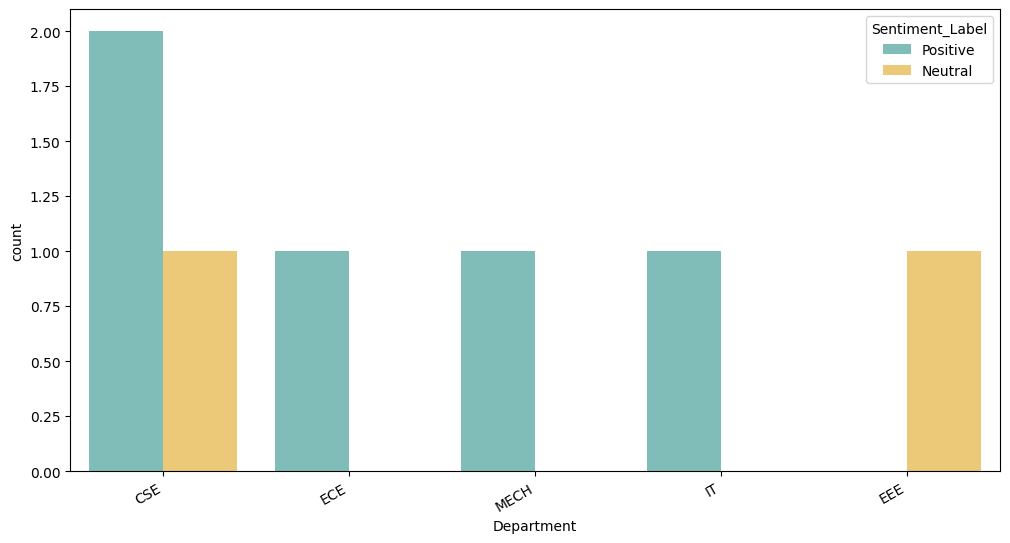

In [ ]:
custom_palette = {'Positive': '#76C7C0', 'Neutral': '#FFD166', 'Negative': '#EF476F'}
sorted_departments = df['Department'].value_counts().index
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df, x='Department', hue='Sentiment_Label',
    order=sorted_departments,
    palette=custom_palette
)
plt.xticks(rotation=30, ha='right')

## ***Feedback Length by Analtyics***

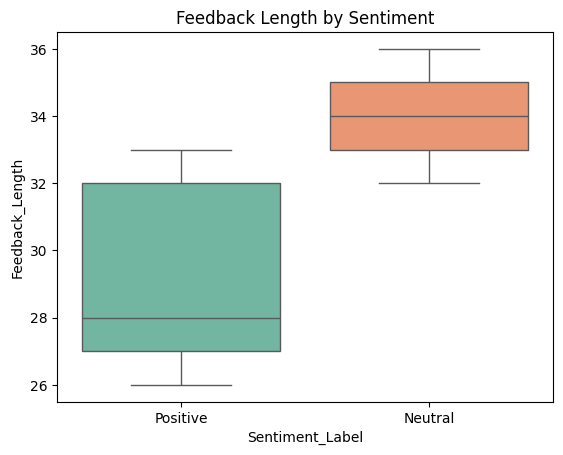

In [ ]:
# --- Feedback Length by Sentiment ---
sns.boxplot(data=df, x='Sentiment_Label', y='Feedback_Length', hue='Sentiment_Label', palette='Set2')
plt.title("Feedback Length by Sentiment")
plt.show()

# *Event-Level Sentiment & Rating Summary*

In [ ]:
print(df.columns)

Index(['Event Name', 'Department', 'Rating', 'Comment', 'Event Date',
       'Sentiment_Polarity', 'Sentiment_Label'],
      dtype='object')


In [ ]:
# Event-Level Summary: Average Rating, Sentiment Score, Most Common Sentiment
event_summary = df.groupby('Event Name').agg(
    Rating=('Rating', 'mean'),
    Sentiment_Polarity=('Sentiment_Polarity', 'mean'),
    Sentiment_Label=('Sentiment_Label', lambda x: x.mode()[0])  # Handles ties and is safer than idxmax
).reset_index()


# Optional: Round values for cleaner display
event_summary['Rating'] = event_summary['Rating'].round(2)
event_summary['Sentiment_Polarity'] = event_summary['Sentiment_Polarity'].round(3)
 #

# Display the summary
print("Event Feedback Summary:")
display(event_summary.head())

Event Feedback Summary:


,Event Name,Rating,Sentiment_Polarity,Sentiment_Label
0,Cultural Fest,3.0,0.600,Positive
1,Hackathon,5.0,0.688,Positive
2,Seminar,4.0,0.520,Positive
3,Tech Talk,3.0,0.500,Neutral
4,Workshop,4.5,0.125,Neutral


In [ ]:
top_events = event_summary.sort_values(by='Rating', ascending=False).head(5)

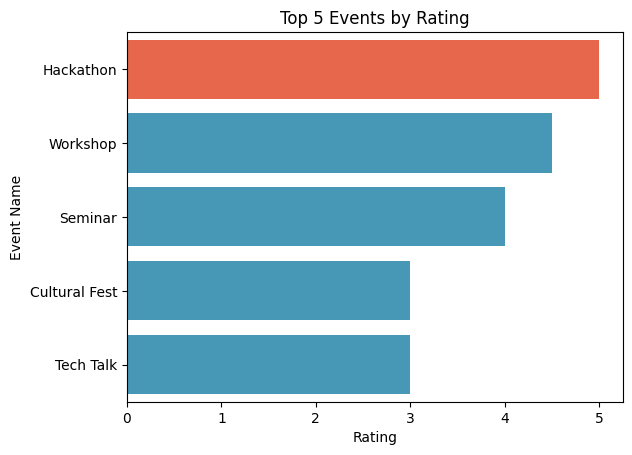

In [ ]:
#Highlight Top Performer
colors = ['#33A1C9'] * 5
colors[0] = '#FF5733'  # Highlight the highest-rated event
sns.barplot(data=top_events, x='Rating', y='Event Name', hue='Event Name', palette=colors, legend=False)
plt.title("Top 5 Events by Rating")
plt.show()

# **N-Gram Analysis (Top Bigrams/Trigrams)**

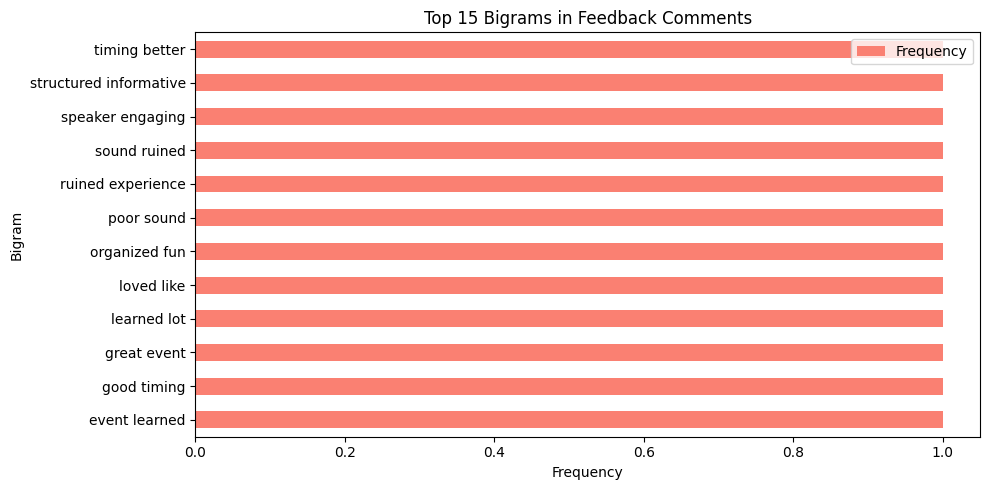

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd
cv = CountVectorizer(ngram_range=(2, 2), stop_words='english')
ngrams = cv.fit_transform(df['Comment'])
ngram_freq = pd.DataFrame(ngrams.sum(axis=0), columns=cv.get_feature_names_out()).T
ngram_freq.columns = ['Frequency']
ngram_freq = ngram_freq.sort_values(by='Frequency', ascending=False).head(15)

ngram_freq.plot(kind='barh', figsize=(10, 5), color='salmon')
plt.title('Top 15 Bigrams in Feedback Comments')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

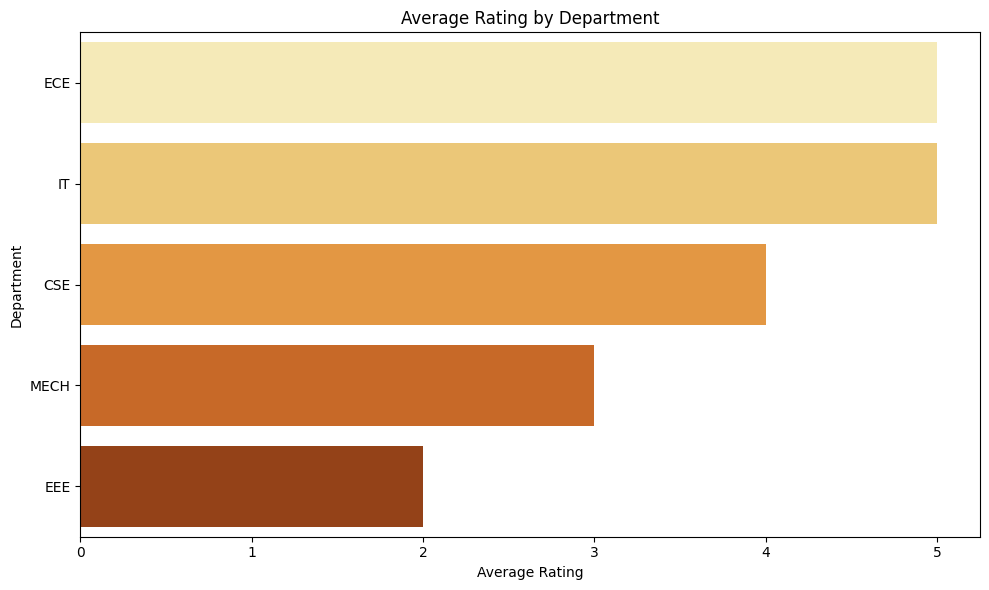

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Group and aggregate by Department
dept_sentiment = df.groupby('Department').agg({
'Rating': 'mean',
'Sentiment_Polarity': 'mean'
}).reset_index()
# Sort by Rating
dept_sentiment = dept_sentiment.sort_values('Rating', ascending=False)
# Create the barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=dept_sentiment,
    x='Rating',
    y='Department',
    hue='Department',       # Fixes the palette deprecation warning
    palette='YlOrBr',
    legend=False
 )
 # Add title and labels
plt.title('Average Rating by Department')
plt.xlabel('Average Rating')
plt.ylabel('Department')
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
best_event = df.groupby('Event Name')['Rating'].mean().idxmax()
worst_event = df.groupby('Event Name')['Rating'].mean().idxmin()
avg_rating = df['Rating'].mean()


print("### Key Findings:")
print(f"- ✅ The average satisfaction rating across all events is **{avg_rating:.2f}**, indicating generally positive experiences.")
print(f"- 🏆 The **highest-rated event** was **{best_event}**, while the **lowest-rated** was **{worst_event}**.")

# Calculate department-wise average ratings again for the report
dept_avg_report = df.groupby('Department')['Rating'].mean().sort_values(ascending=False)
print("\n- 🧑‍🎓 Top-performing departments based on average ratings:")
for dept, rating in dept_avg_report.items():
    print(f"  - {dept}: {rating:.2f}")

print("\n- 🧠 Sentiment analysis shows:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / sentiment_counts.sum()) * 100
    print(f"  - **{sentiment}**: {percentage:.1f}%")


### Key Findings:
- ✅ The average satisfaction rating across all events is **3.86**, indicating generally positive experiences.
- 🏆 The **highest-rated event** was **Hackathon**, while the **lowest-rated** was **Cultural Fest**.

- 🧑‍🎓 Top-performing departments based on average ratings:
  - ECE: 5.00
  - IT: 5.00
  - CSE: 4.00
  - MECH: 3.00
  - EEE: 2.00

- 🧠 Sentiment analysis shows:
  - **Positive**: 71.4%
  - **Neutral**: 28.6%


# **🔍 KEY INSIGHTS**

✅ Most ratings are on the higher end (4–5), indicating overall satisfaction among attendees.

🧠 Sentiment analysis shows predominantly positive feedback, with a notable portion of neutral comments.

💬 Common positive keywords: “amazing”, “interactive”; Common negative keywords: “late”, “noise”.

⚖ Some events with high ratings still received neutral sentiment — suggesting attendees may have enjoyed the event but had certain unspoken issues.

🛠 Technical workshops consistently received the highest ratings, while social/cultural events had more mixed feedback.


# **🎯 STRATEGIC RECOMMENDATIONS**

📌 Maintain and replicate the best practices of consistently high-performing events.

🗳️ Conduct pre-event surveys to align event plans with student expectations.

✍ Encourage more open-ended feedback to capture nuanced experiences.

⏱ Focus on improving event logistics — especially timing and minimizing noise disruptions.

🔄 Revisit and redesign events that show neutral sentiment despite good ratings to uncover hidden improvement areas.






# **🏁 Final Conclusion**

This analysis highlights that while overall student satisfaction with college events is strong, there are opportunities to enhance the experience by addressing subtle but recurring concerns.
By combining quantitative ratings with qualitative sentiment analysis, we gained a deeper understanding of event performance beyond surface-level scores.
Focusing on logistics, timely execution, and student-driven planning will not only maintain positive sentiment but also convert neutral experiences into highly positive ones, ultimately leading to higher engagement and participation in future events.